Epoch 1/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 29.9570
Epoch 2/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 30.0023
Epoch 3/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 30.1781
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


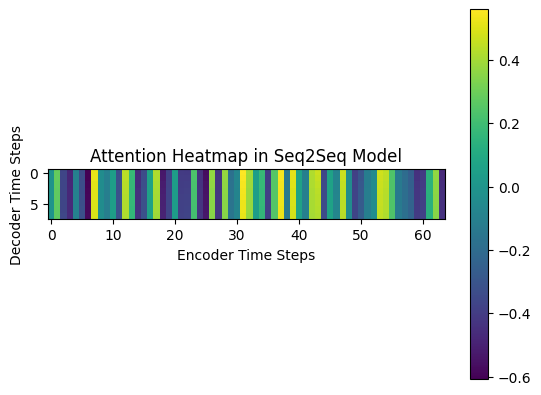

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Attention
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Dummy sequence data
encoder_input_data = np.random.random((100, 10, 20))
decoder_input_data = np.random.random((100, 8, 20))
decoder_target_data = np.random.random((100, 8, 20))

latent_dim = 64

# Encoder
encoder_inputs = Input(shape=(10, 20))
encoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)

# Decoder
decoder_inputs = Input(shape=(8, 20))
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=[state_h, state_c])

# Attention Layer
attention_layer = Attention()
attention_output = attention_layer([decoder_outputs, encoder_outputs])

# Dense output
decoder_dense = Dense(20, activation="softmax")
output = decoder_dense(attention_output)

# Model
model = Model([encoder_inputs, decoder_inputs], output)
model.compile(optimizer='adam', loss='categorical_crossentropy')

# Train model
model.fit([encoder_input_data, decoder_input_data], decoder_target_data, epochs=3)

# Generate attention weights
attention_model = Model([encoder_inputs, decoder_inputs], attention_output)

attention_weights = attention_model.predict([encoder_input_data[:1], decoder_input_data[:1]])

# Convert to heatmap format
heatmap = attention_weights[0]

# Plot Attention Heatmap
plt.imshow(heatmap, cmap='viridis')
plt.colorbar()

plt.xlabel("Encoder Time Steps")
plt.ylabel("Decoder Time Steps")
plt.title("Attention Heatmap in Seq2Seq Model")

plt.show()